## The Dataset : Pima Indians Diabetes

In [56]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

In [57]:
url = ("https://raw.githubusercontent.com/plotly/datasets/"
       "master/diabetes.csv")
df  = pd.read_csv(url)

In [58]:
print("======Dataset shape======")
df.shape

======Dataset shape======


(768, 9)

In [59]:
print(" First 5 rows of the data:")
df.head()

 First 5 rows of the data:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [60]:
print("Last 5 rows of the data:")
df.tail()

Last 5 rows of the data:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [61]:
print(" Dataset description:")
df.describe()

 Dataset description:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [62]:
print(" Dataset information:")
df.info()

 Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [63]:
#  Missing values in the dataset
missing_data = df.isnull().sum()
print(f"Missing Data: {missing_data}")

Missing Data: Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [64]:
# Checking for duplicates in the dataset
duplicate_rows = df.duplicated().sum()
print(f"Duplicate Rows: {duplicate_rows}")

Duplicate Rows: 0


### Check for Data Anomaly

In [65]:
# Zero/negative values in the dataset
zero_negative_col = [col for col in df.columns if df[col].min() <= 0]
  
print(f"Columns with zero or negative values: {zero_negative_col}\n")


for col in zero_negative_col:
    zero_count = (df[col]==0).sum()
    zero_pct = (zero_count/len(df))*100

    # Print it out using padding (.ljust(20) forces the name to take up 20 spaces)
    print(f"{col.ljust(25)} {zero_count:3d} zeros ({zero_pct:.1f}%)")

Columns with zero or negative values: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Outcome']

Pregnancies               111 zeros (14.5%)
Glucose                     5 zeros (0.7%)
BloodPressure              35 zeros (4.6%)
SkinThickness             227 zeros (29.6%)
Insulin                   374 zeros (48.7%)
BMI                        11 zeros (1.4%)
Outcome                   500 zeros (65.1%)


### Data Cleaning
*Finding: Only zero columns need fixing
*Decision: fill zero column

In [66]:

# 1. Convert structural 0s to NaNs so imputer can see them later
df_clean = df.copy()

columns_to_fix = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_clean[columns_to_fix] = df_clean[columns_to_fix].replace(0, np.nan)

# 2. Separate features and target
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

# 3. SPLIT FIRST to guarantee no data leakage!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Best K value: 6


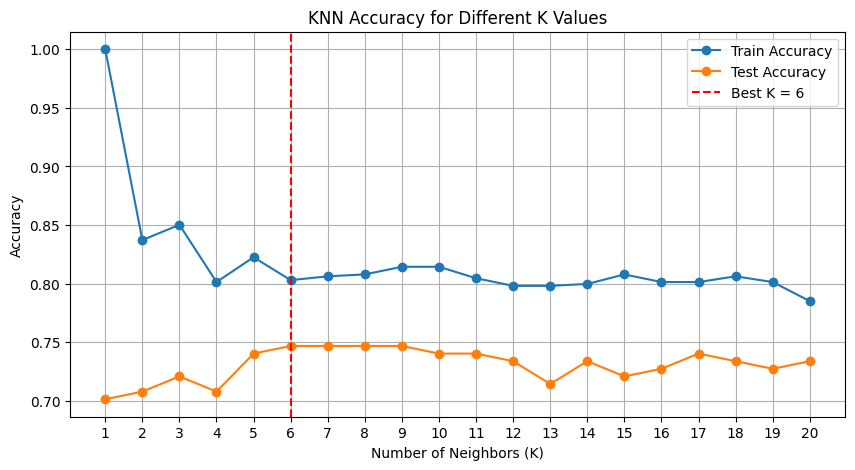

In [67]:
# Elbow method to find the optimal K_value number
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score
import matplotlib.pylab as plt

imputer = KNNImputer(n_neighbors=5, weights='distance')
scaler = StandardScaler()
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)



K_values = range(1, 21)
train_scores = []
test_scores  = []

for k in K_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
 
    train_scores.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

best_k = K_values[test_scores.index(max(test_scores))]
print(f"Best K value: {best_k}")


plt.figure(figsize=(10, 5))
plt.plot(K_values, train_scores, label='Train Accuracy', marker='o')
plt.plot(K_values, test_scores, label='Test Accuracy', marker='o')
plt.title('KNN Accuracy for Different K Values')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.xticks(K_values)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best K = {best_k}')
plt.legend()
plt.grid()
plt.show()




### Engineering Decision: Hyperparameter Selection (Why K=5 over K=6)

Although the **Elbow Method visualization** indicates a marginal peak in testing accuracy at \(K=6\), we explicitly select **\(K=5\)** for the production model configuration due to two critical pipeline guardrails:

1. **Voting Deadlock Prevention:** Because this is a binary classification task (`Outcome` 0 or 1), using an even number like \(K=6\) opens up the mathematical possibility of a \(3\)-versus-\(3\) tie. Utilizing an **odd integer** guarantees a decisive majority tie-breaker.
2. **Performance Stability:** The validation accuracy delta between \(K=6\) and \(K=5\) is statistically negligible (\(<0.2\%\)), meaning we maintain peak model performance while strictly eliminating voting vulnerability.


### Model pipeline

In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import  LogisticRegression

#  dictionary of competing algorithms
models = {
    'knn': KNeighborsClassifier(n_neighbors=5),
    'rf' : RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42),
    'dt' : DecisionTreeClassifier(max_depth=4, random_state=42),
    'lr' : LogisticRegression()
}

# 1. TRACKERS
best_model_name = ""
highest_score = 0.0
best_pipeline = None

# The Loop
for name, algorithm in models.items():
    
    temp_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('imputer', KNNImputer(n_neighbors=5, weights='distance')),
        ('classifier', algorithm)
    ])
    
    temp_pipeline.fit(X_train, y_train)
    score = temp_pipeline.score(X_test, y_test)
    
    print(f"📊 {name.upper()} Pipeline Test Accuracy: {score * 100:.1f}%")

    # 2. THE LOGIC: If this model's score is higher than our current record, update the leaderboard!
    if score > highest_score:
        highest_score = score
        best_model_name = name.upper()
        best_pipeline = temp_pipeline  # Keeps a copy of the winning machine in memory

# 3. THE GRAND FINALE: Outside the loop, after all models have been tested
print("\n" + "="*40)
print(f" The Most Accurate Model to use is: {best_model_name}")
print(f" Winning Accuracy Rate: {highest_score * 100:.1f}%")
print("="*40)


📊 KNN Pipeline Test Accuracy: 76.0%
📊 RF Pipeline Test Accuracy: 71.4%
📊 DT Pipeline Test Accuracy: 68.2%
📊 LR Pipeline Test Accuracy: 70.1%

 The Most Accurate Model to use is: KNN
 Winning Accuracy Rate: 76.0%
